In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [13]:
import pandas as pd
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"
df = pd.read_csv(url, sep=r'\s+', header=None, na_values='?')
display(df.head())

,0,1,2,3,4,5,6,7,8
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


In [11]:
df.isnull().sum()

,0
0,0
1,0
2,0
3,0
4,0
5,0
6,0
7,0
8,0


In [14]:
# Identify the column with null values (column 3)
median_value = df[3].median()

# Fill null values in column 3 with the calculated median
df[3] = df[3].fillna(median_value)

# Verify that null values have been handled
display(df.isnull().sum())

,0
0,0
1,0
2,0
3,0
4,0
5,0
6,0
7,0
8,0


In [15]:
df.columns = ['MPG', 'Cylinders', 'Displacement', 'Horsepower', 'Weight',
                'Acceleration', 'Model Year', 'Origin', 'Car Name']
display(df.head())

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin,Car Name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


In [16]:
df = df.drop(columns=['Car Name'])
display(df.head())

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,1


In [17]:
display(df.isnull().sum())

,0
MPG,0
Cylinders,0
Displacement,0
Horsepower,0
Weight,0
Acceleration,0
Model Year,0
Origin,0


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   MPG           398 non-null    float64
 1   Cylinders     398 non-null    int64  
 2   Displacement  398 non-null    float64
 3   Horsepower    398 non-null    float64
 4   Weight        398 non-null    float64
 5   Acceleration  398 non-null    float64
 6   Model Year    398 non-null    int64  
 7   Origin        398 non-null    int64  
dtypes: float64(5), int64(3)
memory usage: 25.0 KB


In [21]:
df.describe()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.304020,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,38.222625,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,76.000000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,125.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


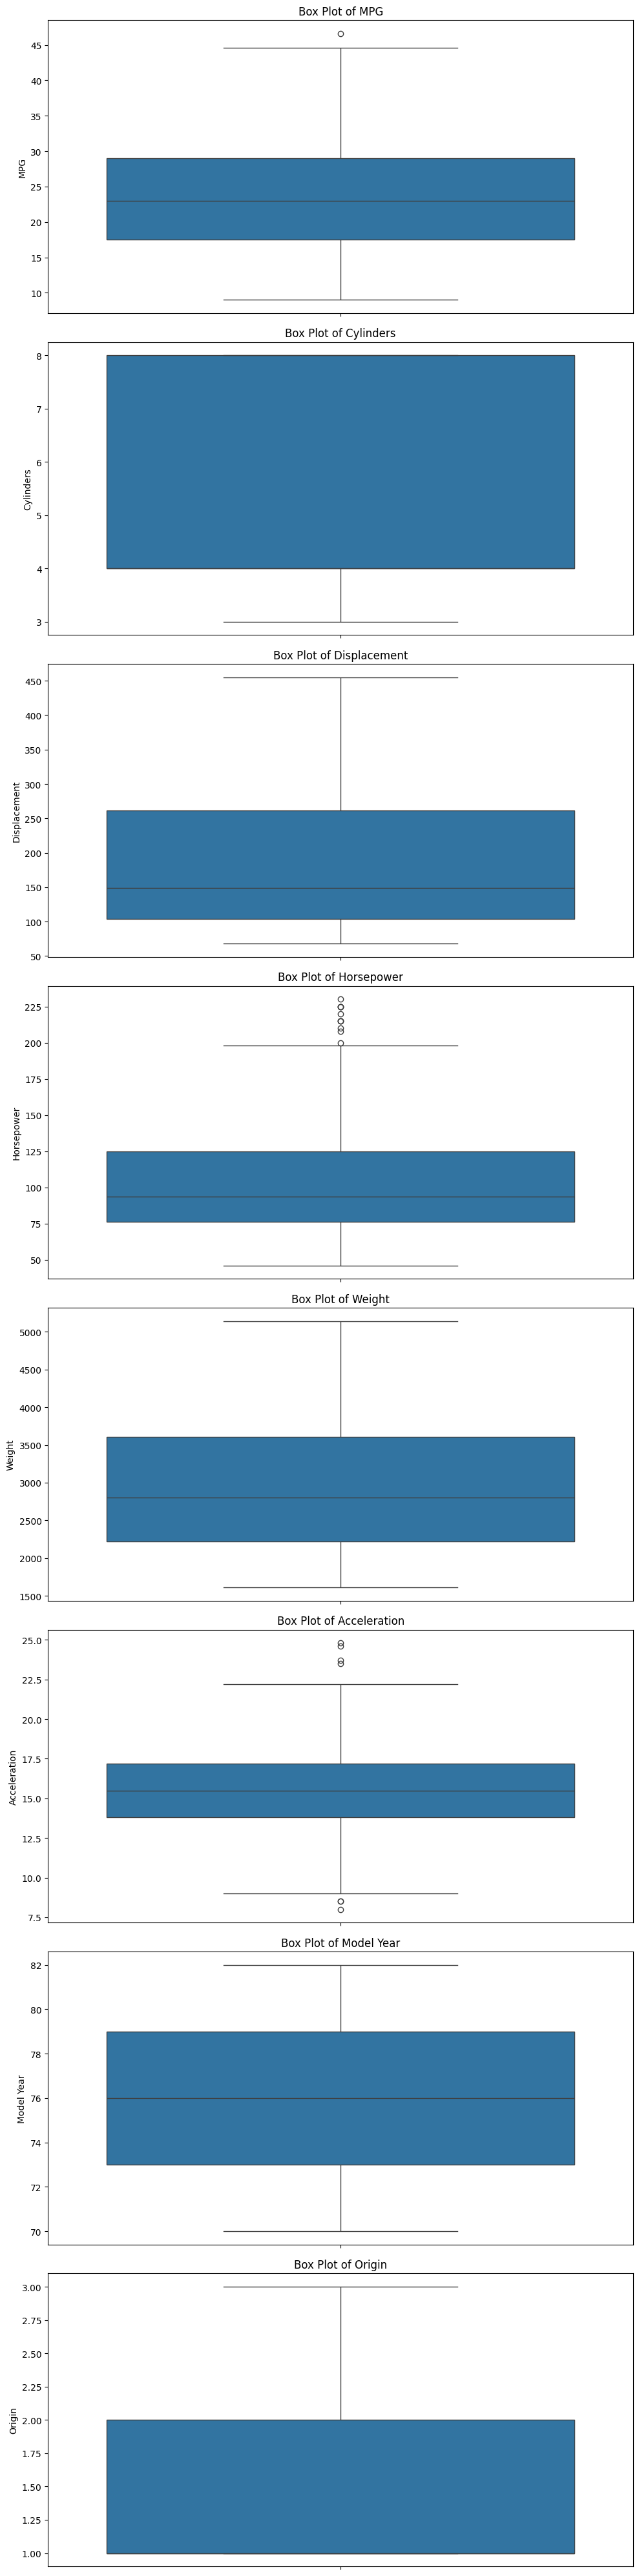

In [26]:
fig, axes = plt.subplots(nrows=len(num_cols), ncols=1, figsize=(10, 5 * len(num_cols)))

if len(num_cols) == 1:
    axes = [axes]

for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f'Box Plot of {col}')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

### Handling Outliers using IQR Method

I will now address outliers in the numerical columns of the DataFrame using the Interquartile Range (IQR) method. Values below `Q1 - 1.5 * IQR` or above `Q3 + 1.5 * IQR` will be capped to these boundary values.

In [27]:
# Create a copy of the DataFrame to avoid modifying the original 'df' in place for this operation
df_cleaned = df.copy()

# Identify numerical columns, excluding 'Origin' and 'Model Year' as they are categorical representations
# and 'Cylinders' has a limited number of unique values.
# We will focus on 'MPG', 'Displacement', 'Horsepower', 'Weight', 'Acceleration'

# Using a subset of num_cols that are more likely to have meaningful outliers for capping
columns_to_check_outliers = ['MPG', 'Displacement', 'Horsepower', 'Weight', 'Acceleration']

for col in columns_to_check_outliers:
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap outliers
    df_cleaned[col] = np.where(df_cleaned[col] < lower_bound, lower_bound, df_cleaned[col])
    df_cleaned[col] = np.where(df_cleaned[col] > upper_bound, upper_bound, df_cleaned[col])

print("Outliers in selected numerical columns have been capped using the IQR method.")
display(df_cleaned.describe())

Outliers in selected numerical columns have been capped using the IQR method.


,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.513693,5.454774,193.425879,103.790201,2970.424623,15.552010,76.010050,1.572864
std,7.813400,1.701004,104.269838,36.770468,846.841774,2.693089,3.697627,0.802055
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.800000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,76.000000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,125.000000,3608.000000,17.175000,79.000000,2.000000
max,46.250000,8.000000,455.000000,198.500000,5140.000000,22.200000,82.000000,3.000000


To visually confirm the effect of capping, let's re-plot the box plots for the modified DataFrame `df_cleaned`.

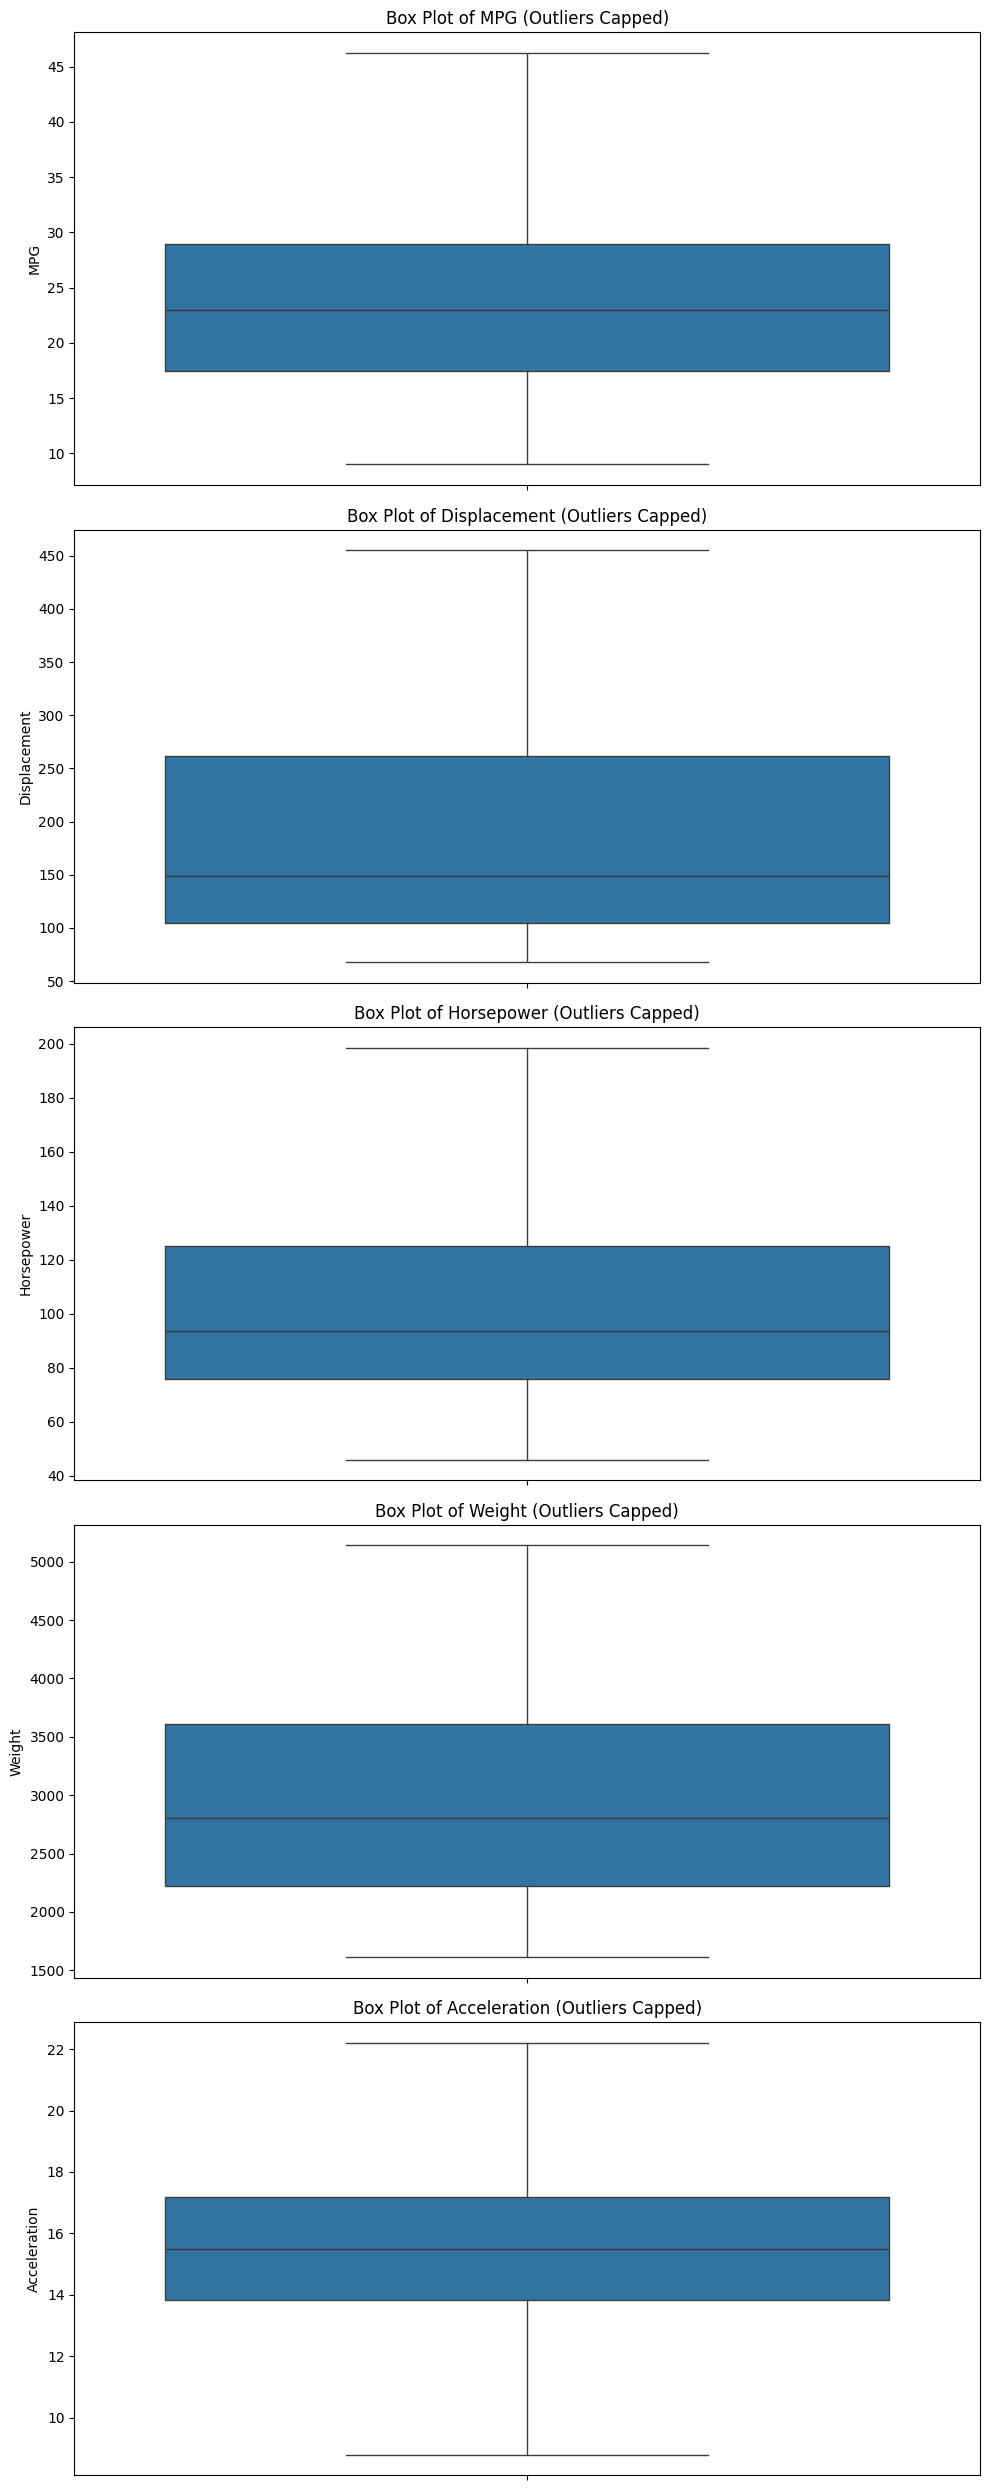

In [29]:
# Re-plotting box plots for the cleaned DataFrame

fig_cleaned, axes_cleaned = plt.subplots(nrows=len(columns_to_check_outliers), ncols=1, figsize=(10, 5 * len(columns_to_check_outliers)))

if len(columns_to_check_outliers) == 1:
    axes_cleaned = [axes_cleaned]

for i, col in enumerate(columns_to_check_outliers):
    sns.boxplot(y=df_cleaned[col], ax=axes_cleaned[i])
    axes_cleaned[i].set_title(f'Box Plot of {col} (Outliers Capped)')
    axes_cleaned[i].set_ylabel(col)

plt.tight_layout()
plt.show()

In [30]:
df.corr()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
MPG,1.000000,-0.775396,-0.804203,-0.773453,-0.831741,0.420289,0.579267,0.563450
Cylinders,-0.775396,1.000000,0.950721,0.841284,0.896017,-0.505419,-0.348746,-0.562543
Displacement,-0.804203,0.950721,1.000000,0.895778,0.932824,-0.543684,-0.370164,-0.609409
Horsepower,-0.773453,0.841284,0.895778,1.000000,0.862442,-0.686590,-0.413733,-0.452096
Weight,-0.831741,0.896017,0.932824,0.862442,1.000000,-0.417457,-0.306564,-0.581024
Acceleration,0.420289,-0.505419,-0.543684,-0.686590,-0.417457,1.000000,0.288137,0.205873
Model Year,0.579267,-0.348746,-0.370164,-0.413733,-0.306564,0.288137,1.000000,0.180662
Origin,0.563450,-0.562543,-0.609409,-0.452096,-0.581024,0.205873,0.180662,1.000000


In [31]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df_cleaned.drop('MPG', axis=1)  # All columns except 'MPG' as features
y = df_cleaned['MPG']               # 'MPG' as the target variable

# Perform the train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (318, 7)
X_test shape: (80, 7)
y_train shape: (318,)
y_test shape: (80,)


In [33]:
X_test

,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
198,4,91.0,53.0,1795.0,17.4,76,3
396,4,120.0,79.0,2625.0,18.6,82,1
33,6,232.0,100.0,2634.0,13.0,71,1
208,8,318.0,150.0,3940.0,13.2,76,1
93,8,318.0,150.0,4237.0,14.5,73,1
...,...,...,...,...,...,...,...
249,8,260.0,110.0,3365.0,15.5,78,1
225,6,250.0,110.0,3520.0,16.4,77,1
367,4,112.0,88.0,2605.0,19.6,82,1
175,4,90.0,70.0,1937.0,14.0,75,2


In [34]:
from sklearn.preprocessing import MinMaxScaler

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Fit the scaler on the training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert the scaled arrays back to DataFrames for easier inspection
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("Min-Max Scaling applied successfully!")
display(X_train_scaled.head())
display(X_test_scaled.head())

Min-Max Scaling applied successfully!


,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
0,1.0,0.609819,0.681967,0.516019,0.238806,0.000000,0.0
1,0.2,0.074935,0.275410,0.146583,0.425373,0.000000,1.0
2,0.2,0.059432,0.144262,0.116813,0.701493,1.000000,1.0
3,0.2,0.059432,0.091803,0.053020,0.567164,0.666667,1.0
4,0.2,0.121447,0.321311,0.306493,0.462687,0.416667,0.5


,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
0,0.2,0.059432,0.045902,0.051602,0.641791,0.500000,1.0
1,0.2,0.134367,0.216393,0.286929,0.731343,1.000000,0.0
2,0.6,0.423773,0.354098,0.289481,0.313433,0.083333,0.0
3,1.0,0.645995,0.681967,0.659768,0.328358,0.500000,0.0
4,1.0,0.645995,0.681967,0.743975,0.425373,0.250000,0.0


In [36]:
X_test_scaled

,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
0,0.2,0.059432,0.045902,0.051602,0.641791,0.500000,1.0
1,0.2,0.134367,0.216393,0.286929,0.731343,1.000000,0.0
2,0.6,0.423773,0.354098,0.289481,0.313433,0.083333,0.0
3,1.0,0.645995,0.681967,0.659768,0.328358,0.500000,0.0
4,1.0,0.645995,0.681967,0.743975,0.425373,0.250000,0.0
...,...,...,...,...,...,...,...
75,1.0,0.496124,0.419672,0.496739,0.500000,0.666667,0.0
76,0.6,0.470284,0.419672,0.540686,0.567164,0.583333,0.0
77,0.2,0.113695,0.275410,0.281259,0.805970,1.000000,0.0
78,0.2,0.056848,0.157377,0.091863,0.388060,0.416667,0.5


### Linear Regression Model Training and Evaluation

In [37]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Initialize the Linear Regression model
linear_model = LinearRegression()

# Train the model using the scaled training data
linear_model.fit(X_train_scaled, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [38]:
# Make predictions on the scaled test data
y_pred = linear_model.predict(X_test_scaled)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

# Optionally, display the first few predictions vs actual values
predictions_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
display(predictions_df.head())

Mean Squared Error (MSE): 8.19
R-squared (R2): 0.85


,Actual,Predicted
198,33.0,32.968004
396,28.0,29.460215
33,19.0,21.461944
208,13.0,16.735503
93,14.0,12.473724


In [39]:
# Make predictions on the scaled training data
y_train_pred = linear_model.predict(X_train_scaled)

# Evaluate the model on the training set
mse_train = mean_squared_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)

print(f"Training Mean Squared Error (MSE): {mse_train:.2f}")
print(f"Training R-squared (R2): {r2_train:.2f}")

# Optionally, display the first few training predictions vs actual values
predictions_train_df = pd.DataFrame({'Actual': y_train, 'Predicted': y_train_pred})
display(predictions_train_df.head())

Training Mean Squared Error (MSE): 11.60
Training R-squared (R2): 0.81


,Actual,Predicted
3,16.0,15.072575
18,27.0,25.312217
376,37.0,35.871055
248,36.1,34.334447
177,23.0,24.357738


In [40]:
# Display the model coefficients
print("Model Coefficients:")
for feature, coef in zip(X.columns, linear_model.coef_):
    print(f"  {feature}: {coef:.4f}")

# Display the model intercept
print(f"\nModel Intercept: {linear_model.intercept_:.4f}")

Model Coefficients:
  Cylinders: -0.6801
  Displacement: 5.3847
  Horsepower: -3.5365
  Weight: -22.7703
  Acceleration: 0.1855
  Model Year: 9.4494
  Origin: 2.6912

Model Intercept: 26.5863


### Polynomial Regression Model (Second Order)

To capture non-linear relationships, we'll apply a second-order polynomial transformation to our features. Then, we'll train a new Linear Regression model on these transformed features and evaluate its performance.

In [46]:
from sklearn.preprocessing import PolynomialFeatures

# Initialize PolynomialFeatures with degree 2
poly = PolynomialFeatures(degree=3, include_bias=False)

# Fit and transform the training data
X_train_poly = poly.fit_transform(X_train_scaled)

# Transform the test data (do not fit again to avoid data leakage)
X_test_poly = poly.transform(X_test_scaled)

print(f"Original number of features: {X_train_scaled.shape[1]}")
print(f"Number of features after polynomial transformation: {X_train_poly.shape[1]}")

Original number of features: 7
Number of features after polynomial transformation: 119


In [47]:
# Initialize a new Linear Regression model
poly_linear_model = LinearRegression()

# Train the model using the polynomial features
poly_linear_model.fit(X_train_poly, y_train)

print("Polynomial Linear Regression model trained successfully!")

Polynomial Linear Regression model trained successfully!


In [43]:
# Make predictions on the polynomial test data
y_pred_poly = poly_linear_model.predict(X_test_poly)

# Evaluate the model
mse_poly = mean_squared_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print(f"Polynomial Model Mean Squared Error (MSE): {mse_poly:.2f}")
print(f"Polynomial Model R-squared (R2): {r2_poly:.2f}")

# Display the first few predictions vs actual values for the polynomial model
predictions_poly_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_poly})
display(predictions_poly_df.head())

Polynomial Model Mean Squared Error (MSE): 6.08
Polynomial Model R-squared (R2): 0.89


,Actual,Predicted
198,33.0,32.206950
396,28.0,30.494640
33,19.0,19.705562
208,13.0,15.188115
93,14.0,13.252652


### Training Metrics for Linear and Polynomial Models

In [44]:
# Make predictions on the polynomial training data
y_train_pred_poly = poly_linear_model.predict(X_train_poly)

# Evaluate the polynomial model on the training set
mse_train_poly = mean_squared_error(y_train, y_train_pred_poly)
r2_train_poly = r2_score(y_train, y_train_pred_poly)

print(f"--- Linear Regression Model (Training) ---")
print(f"Training Mean Squared Error (MSE): {mse_train:.2f}")
print(f"Training R-squared (R2): {r2_train:.2f}")

print(f"\n--- Polynomial Regression Model (Training) ---")
print(f"Training Mean Squared Error (MSE): {mse_train_poly:.2f}")
print(f"Training R-squared (R2): {r2_train_poly:.2f}")

# Optionally, display the first few training predictions vs actual values for the polynomial model
predictions_train_poly_df = pd.DataFrame({'Actual': y_train, 'Predicted': y_train_pred_poly})
display(predictions_train_poly_df.head())

--- Linear Regression Model (Training) ---
Training Mean Squared Error (MSE): 11.60
Training R-squared (R2): 0.81

--- Polynomial Regression Model (Training) ---
Training Mean Squared Error (MSE): 6.73
Training R-squared (R2): 0.89


,Actual,Predicted
3,16.0,15.818822
18,27.0,24.611317
376,37.0,40.441574
248,36.1,34.155935
177,23.0,23.368732
